# Netflix Data Analysis

This project explores the Netflix titles dataset to understand trends in the platform's content library. The analysis focuses on data cleaning, exploratory data analysis (EDA), and visualization to uncover patterns such as content growth over time, netflix growth overtime, top 10 directors and cast, popular genres, and the countries producing the most content.

The analysis was conducted using Python with the Pandas, Seaborn, and Matplotlib libraries.

## Dataset Overview

The dataset contains information about movies and TV shows available on Netflix. Each row represents a title available on the platform.

The dataset includes several features such as:

- Title of the content
- Type (Movie or TV Show)
- Director
- Cast
- Country of production
- Date added to Netflix
- Release year
- Rating
- Duration
- Genres

This dataset allows us to explore trends in Netflix's content library and understand how the platform has evolved over time.

In [9]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

## Data Inspection

The first step in the analysis is inspecting the dataset to understand its structure and identify potential issues.

This includes:
- Checking the number of rows and columns
- Identifying data types
- Detecting missing values
- checking for duplicates

Understanding the dataset structure helps determine what cleaning steps are necessary before analysis.

In [10]:

df=pd.read_csv(r'C:\Users\Admin\Downloads\netflix_titles.csv')
#INSPECTING AND CLEANING

print(df.info())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
None
(8807, 12)
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
d

## Data Cleaning

Real-world datasets often contain missing values, inconsistent formats, or incorrect data types. Before performing analysis, these issues must be addressed.

The following cleaning steps were performed:

- Missing values in the **director**, **cast**, and **country** columns were replaced with "unknown".
- Rows with missing **date_added** values were removed because the date is necessary for time-based analysis.
- Missing **duration** values were also removed.
- The **date_added** column was converted from string format to datetime format.
- rating was converted to strings as some values were in float
- release year column was coverted to string as some values were string

These steps ensure that the dataset is consistent and ready for analysis.

In [11]:

df['director']=df['director'].fillna('unknown')
# i'll now fix the incorrect datatypes then deal with the missing values
# the string date added needs to be converted to datetime
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce',format='mixed')
df.dropna(subset=['date_added'],inplace=True)
# the duration column has 3 missiing values, i'll drop them
df.dropna(subset=['duration'],inplace=True)
# release_year datatype is int, it needs to be converted to datetime
df['release_year']=df['release_year'].astype(int)
#  4 values are floats in the rating, they have to be handled
df['rating']=df['rating'].astype(str)
df.dropna(subset=['rating'],inplace=True)
# cast column has missing values, i'll replace with unknown
df['cast']=df['cast'].fillna('unknown')
# country also has 831 missing values, ill replace with unknown
df['country']=df['country'].fillna('unknown')

## Feature Engineering

Feature engineering involves creating new variables that can help with analysis.

In this project, a new feature called **year_added_to_netflix** was created from the **date_added** column.

This allows us to analyze how the number of titles added to Netflix has changed over time.

In [12]:

df['year_added_to_netflix']=df['date_added'].dt.year


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps uncover patterns and insights in the dataset.

The following questions are explored:

- What is the distribution between Movies and TV Shows on Netflix?
- Which countries produce the most Netflix content?
- How has the Netflix catalog grown over time?
- What are the most common genres on the platform?
- What ratings are most common for Netflix content?

Data visualization techniques are used to better understand these patterns.

In [13]:


#########+++++++++  EXPLORATOR DATA ANALYSIS AND VISUALIZATION


# visualizing which country produced the most movies and tv shows


### Movie vs TV Show Distribution

This visualization shows the distribution of content types on Netflix. It helps us understand whether the platform contains more movies or TV shows.

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


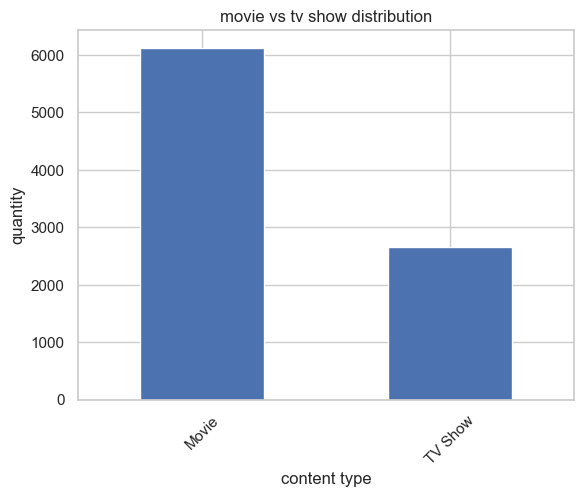

In [27]:

# movie vs tv shows distribution
print(df['type'].value_counts())
types_split=df['type'].str.split(',',expand=True).stack()
types_split.value_counts().head().plot(kind='bar')
plt.xticks(rotation=45)
plt.title('movie vs tv show distribution')
plt.xlabel('content type')
plt.ylabel('quantity')
plt.show()

### Top Countries Producing Netflix Content

This analysis identifies the countries that produce the most content available on Netflix.

Some titles are produced by multiple countries, so the country column was split to count each country separately.

country
United States                                    2809
India                                             972
unknown                                           829
United Kingdom                                    418
Japan                                             243
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 749, dtype: int64
United States     3202
India             1008
unknown            829
United Kingdom     627
 United States     479
                  ... 
 Panama              1
 Namibia             1
 Uganda              1
 East Germany        1
 Montenegro          1
Name: count, Length: 198, dtype: int64


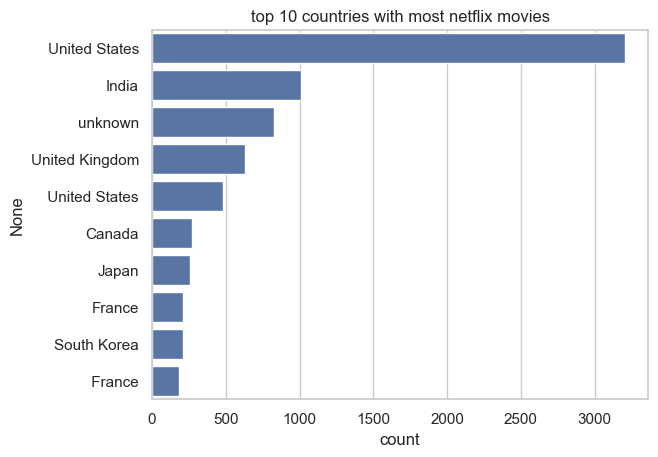

In [15]:

# top 10 countries with most netflix movies
print(df['country'].value_counts())
countries=df['country'].str.split(',',expand=True).stack()
print(countries.value_counts())
sns.set_theme(style='whitegrid')
sns.barplot(x=countries.value_counts().head(10),y=countries.value_counts().head(10).index)
plt.title('top 10 countries with most netflix movies')
plt.show()

### Netflix Content Growth Over Time

This visualization shows how the number of titles added to Netflix has changed over the years.

Analyzing this trend helps illustrate how the platform has expanded its content library.

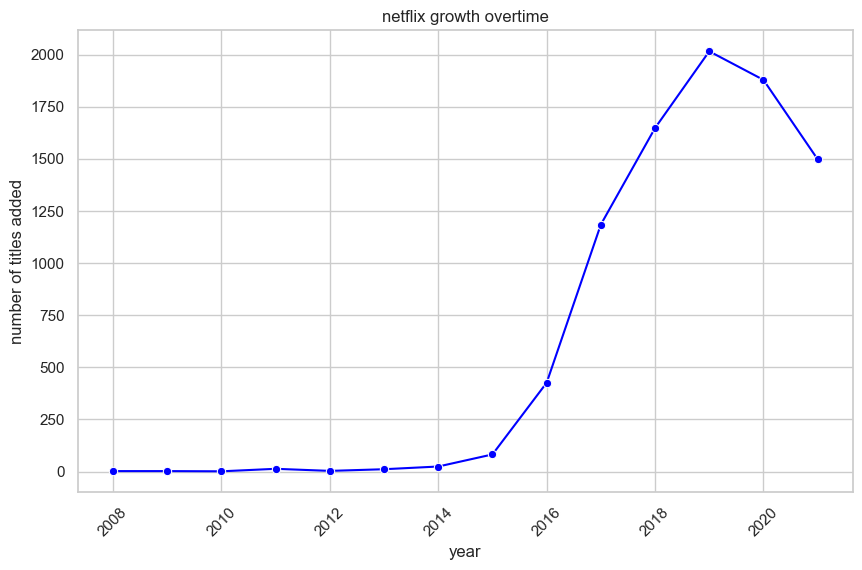

In [16]:


# netflix growth overtime linechart
growth=df['year_added_to_netflix'].value_counts().sort_index()
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))
plt.xticks(rotation=45)
sns.lineplot(x=growth.index, y=growth.values,marker='o',color='blue')
plt.title('netflix growth overtime')
plt.xlabel('year')
plt.ylabel('number of titles added')
plt.show()

### Content Release Year Trends

This analysis shows the number of titles released each year.

It helps reveal how the production of movies and TV shows has evolved over time.

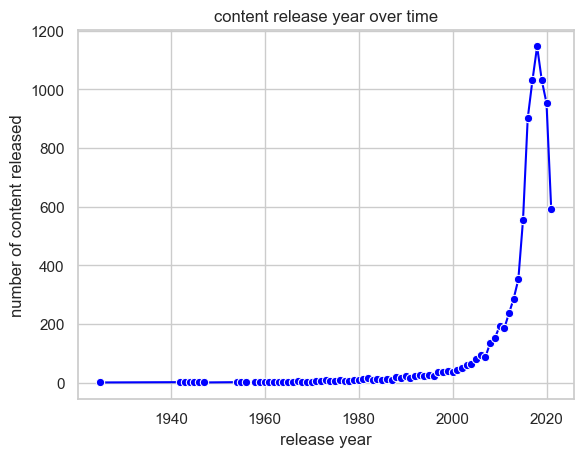

In [17]:


# content releases year overtime
content_growth=df['release_year'].value_counts().sort_index()
sns.set_theme(style='whitegrid')
sns.lineplot(x=content_growth.index, y=content_growth.values,marker='o',color='blue')
plt.title('content release year over time')
plt.xlabel('release year')
plt.ylabel('number of content released')
plt.show()

### Most Popular Genres on Netflix

The dataset contains titles that belong to multiple genres. To analyze genre popularity, the genre column was split so that each genre could be counted individually.

This visualization highlights the most common genres available on Netflix.

 International Movies        2624
Dramas                       1599
Comedies                     1210
Action & Adventure            859
Documentaries                 829
                             ... 
Romantic Movies                 3
Spanish-Language TV Shows       2
LGBTQ Movies                    1
TV Sci-Fi & Fantasy             1
Sports Movies                   1
Name: count, Length: 73, dtype: int64


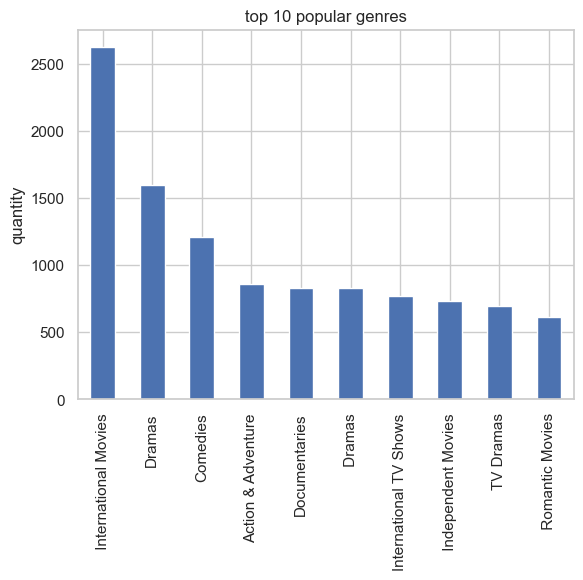

In [26]:

# most popular genre
#print(df['listed_in'].value_counts())
# the genres are mixed so i'll split them
genre=df['listed_in'].str.split(',',expand=True).stack()
print(genre.value_counts())
plt.xticks(rotation=45)
genre.value_counts().head(10).plot(kind='bar')
plt.title('top 10 popular genres')
plt.ylabel('quantity')
plt.show()

**TOP 10 DIRECTORS**
- showing the directors who directed the most amount of content

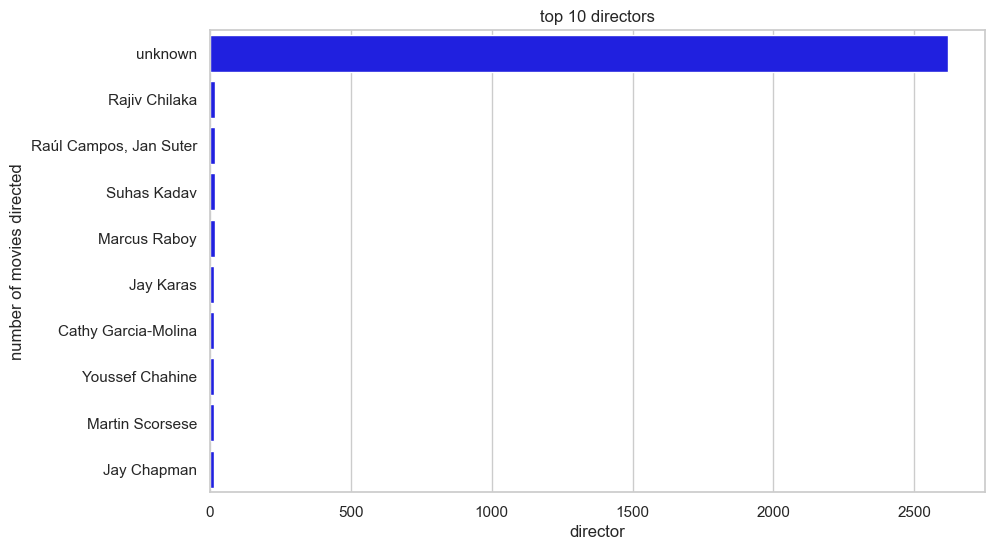

In [19]:

# top 10 directors
directors=df['director'].value_counts().head(10)
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))
sns.barplot(x=directors.values,y=directors.index,color='blue')
plt.title('top 10 directors')
plt.xlabel('director')
plt.ylabel('number of movies directed')
plt.show()

**TOP CAST FEATURING IN NETFLIX CONTENT**

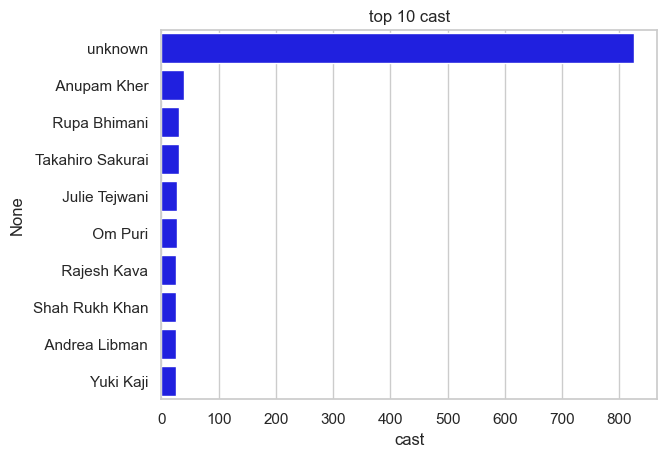

In [23]:

# top cast
top_cast=df['cast'].str.split(',',expand=True).stack()
top_cast_t=top_cast.value_counts().head(10)
sns.barplot(x=top_cast_t.values,y=top_cast_t.index,color='blue')
plt.title('top 10 cast')
plt.xlabel('cast')
plt.show()

### Ratings Distribution

This chart shows the distribution of content ratings on Netflix. Ratings indicate the intended audience for the content, such as general audiences, teenagers, or mature viewers.

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


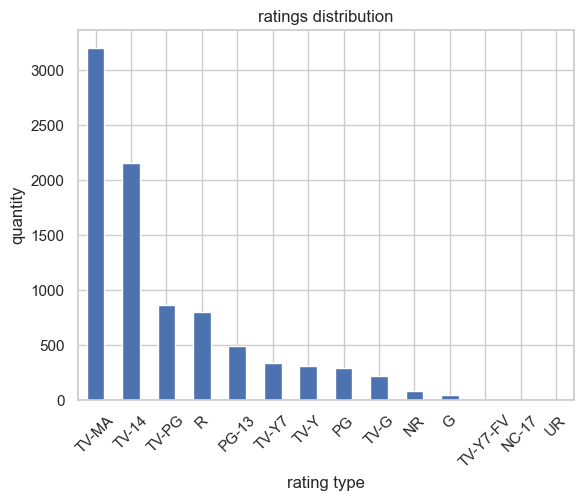

In [21]:

# RATINGS DISTRIBUTION
print(df['rating'].value_counts())
df['rating'].value_counts().plot(kind='bar')
plt.xticks(rotation=45)
plt.title('ratings distribution')
plt.xlabel('rating type')
plt.ylabel('quantity')
plt.show()

### Correlation Analysis

A correlation heatmap is used to examine relationships between numerical variables in the dataset.

The values range from -1 to 1, where:

- **1** indicates a strong positive relationship
- **0** indicates no relationship
- **-1** indicates a strong negative relationship

The heatmap helps identify potential relationships between variables.

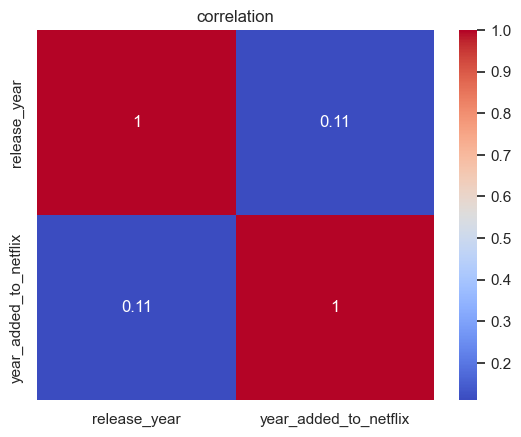

In [22]:

# heatmap
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('correlation')
plt.show()
